# Workshop - Clustering Project
- Complete items 1 - 4 and submit into CANVAS.
- Item 5 is optional.

## 1. Data Prep
You need to complete the following:
1. Read in the data file: wholesale_clients.csv
2. Remove the unused columns
3. standardize the data

In [58]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [59]:
# 1. Read in the data file wholesale_clients.csv
data = pd.read_csv('wholesale_clients.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [60]:
# 2. Remove the Channel (restaurant, hotel, etc.) and Region columns since they are not fields we want to model on
columns_to_drop = ['Channel', 'Region']
data = data.drop(columns=columns_to_drop)

data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [61]:
# 3. Standardize the data
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


## 2. Compare Different Clustering Techniques
For each of the following FOUR models, fit the model on the scaled data, note down the number of data points in each cluster and record the silhouette score:
1. K-Means with 3 clusters
2. K-Means with 5 clusters
3. Hierarchical Clustering with 5 clusters
4. DBSCAN with esp = 3.5, min_samples = 2 clusters

### 2.1. K-Means Clustering with 3 clusters


In [75]:
from collections import Counter

kmeans3 = KMeans(n_clusters = 3, random_state=42, n_init='auto')
kmeans3_label = kmeans3.fit_predict(data_scaled)

kmeans3_count = Counter(kmeans3_label)

### 2.2. K-Means Clustering with 5 clusters



In [76]:
kmeans5 = KMeans(n_clusters = 5, random_state=42, n_init='auto')
kmeans5_label = kmeans5.fit_predict(data_scaled)

kmeans5_count = Counter(kmeans5_label)

### 2.3. Hierarchical Clustering with 5 clusters


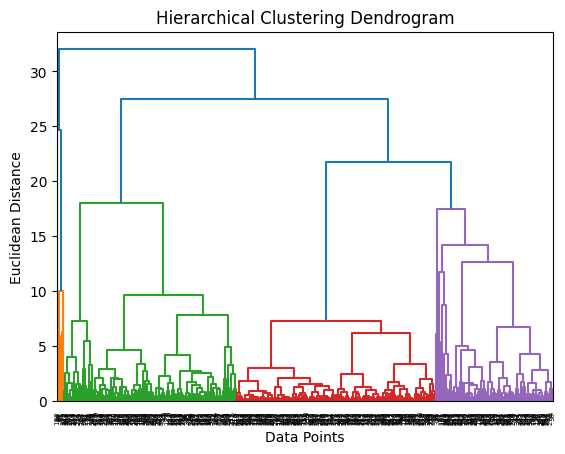

In [64]:
from scipy.cluster.hierarchy import linkage, dendrogram


linkage_matrix = linkage(data_scaled, method='ward')
dendrogram_info = dendrogram(linkage_matrix, color_threshold=20)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance");

### 2.4. DBSCAN with esp = 3.5, min_samples = 2 clusters

In [65]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(data_scaled)
dbscan_count = Counter(dbscan_labels)
dbscan_count

Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})

## 3. Recommend Client Segments
Based on the comparison, select the best model, and review the results with the best model:
1. Choose the best model
2. Plot the graph of the cluster centers
3. Name the clusters
4. Clearly state what you would recommend as client segments and how you would better support those clients


In [67]:
# use the defined print_metrics function to print the results for the FOUR models
def print_metrics(model, data):
    print(model)
    print(Counter(model.labels_))
    print(silhouette_score(data, model.labels_))

KMeans(n_clusters=3, random_state=42)
Counter({np.int32(0): 350, np.int32(1): 53, np.int32(2): 37})
0.4582633767207058


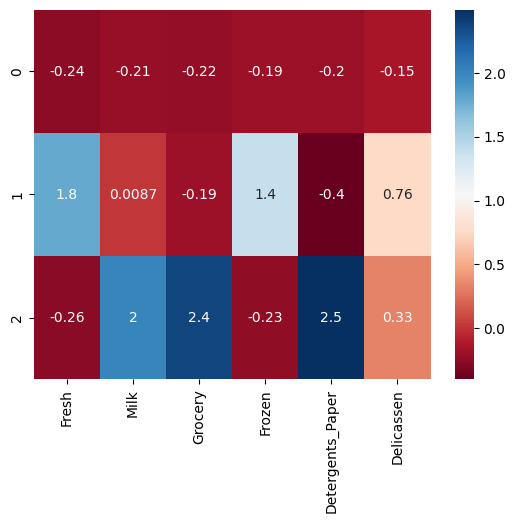

In [78]:
print_metrics(kmeans3, data_scaled)

import seaborn as sns

# Plot the cluster centers
cluster_centers3 = pd.DataFrame(kmeans3.cluster_centers_, columns=data_scaled.columns)
sns.heatmap(cluster_centers3, cmap='RdBu', annot=True);

In [84]:
print_metrics(kmeans5, data_scaled)

KMeans(n_clusters=5, random_state=42)
Counter({np.int32(3): 272, np.int32(0): 96, np.int32(1): 59, np.int32(2): 11, np.int32(4): 2})
0.36890127429678055


In [81]:
print_metrics(agg, data_scaled)

AgglomerativeClustering(n_clusters=5)
Counter({np.int64(4): 177, np.int64(0): 153, np.int64(2): 104, np.int64(1): 5, np.int64(3): 1})
0.23988371669170097


In [83]:
print_metrics(dbscan, data_scaled)

DBSCAN(eps=3.5, min_samples=2)
Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})
0.740283564230615


## 4. Predict the Cluster of a New Client using KMeans predict

In [72]:
# 1. Given this new client, determine which cluster they fall into
new_client = pd.DataFrame([np.array([20000, 20000, 25000, 600, 20000, 1000])], columns=data.columns)
new_client

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,20000,20000,25000,600,20000,1000


In [73]:
# 2. Scale the new client data using the same scaler object from the Data Prep step
new_client_scaled = pd.DataFrame(scaler.transform(new_client), columns=data.columns)
new_client_scaled

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.633241,1.926718,1.796047,-0.509766,3.594487,-0.186329


In [74]:
# 3. Make a prediction using the K-Means model with 3 clusters
cluster_id = kmeans3.predict(new_client_scaled)[0]
print("New client cluster:", cluster_id)

New client cluster: 2


In [ ]:
# 4. Which cluster does the new client belong to? Cluster 2, buying a lot of grocery and detergents / paper items

## 5. (Optional) This session is optional, it is not mandatory for submission.
- Tune the parameter for K-Means:
1. Write a loop to fit models with 2-15 clusters for KMeans
2. Plot Elbow method 
3. Identify the elbow of the plot and fit a KMeans model just for that number of clusters
4. Find the number of clients in each cluster
5. Create a heat map of the cluster centers
6. create a silhouette scores plot instead of an inertia plot
- Tune DBSCAN
1. write a tune_dbscan function to loop through of the combinations of eps and min_samples
2. apply the dune_dbscan function on the scaled data
3. sort the results by highest silhouette score

End of Workshop.